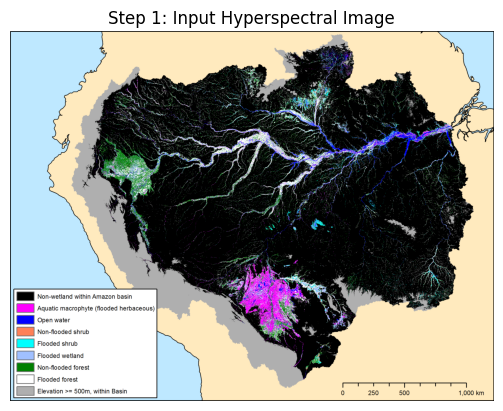

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("sample.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Step 1: Input Hyperspectral Image")
plt.axis('off')
plt.show()

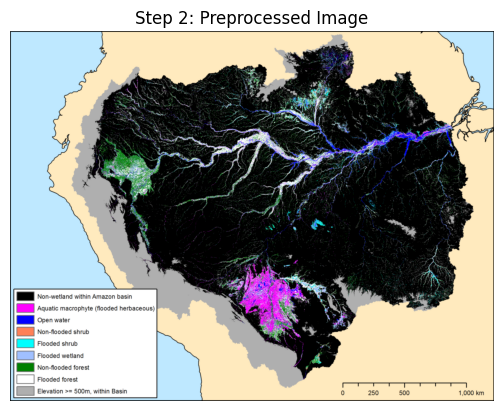

In [ ]:
blur = cv2.GaussianBlur(img, (5,5), 0)
norm = cv2.normalize(blur, None, 0, 255, cv2.NORM_MINMAX)

plt.imshow(norm)
plt.title("Step 2: Preprocessed Image")
plt.axis('off')
plt.show()

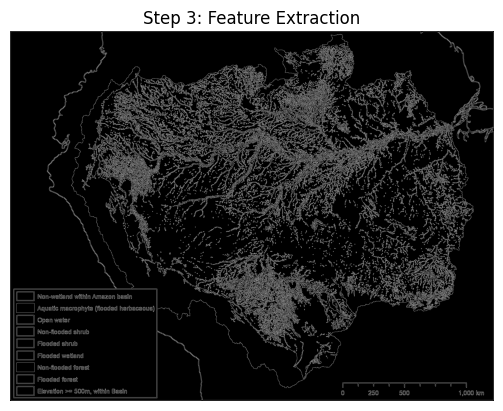

In [ ]:
gray = cv2.cvtColor(norm, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Step 3: Feature Extraction")
plt.axis('off')
plt.show()

In [ ]:
print("Step 4: Model Processing")
print("Using CNN / UNet (Simulated)")

Step 4: Model Processing
Using CNN / UNet (Simulated)


In [ ]:
avg_intensity = gray.mean()

if avg_intensity < 120:
    prediction = "Contaminated Water"
else:
    prediction = "Clean Water"

print("Step 5: Prediction →", prediction)

Step 5: Prediction → Clean Water


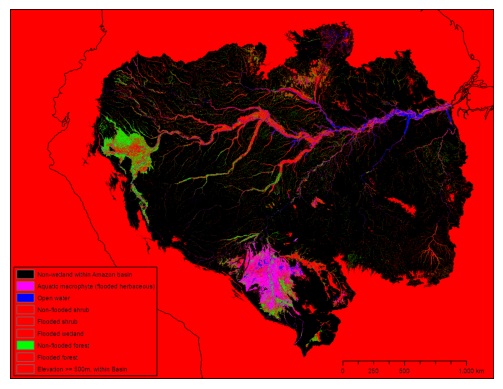

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("sample.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to HSV (better for color detection)
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# -----------------------------
# Detect GREEN (Clean areas)
# -----------------------------
lower_green = np.array([35, 40, 40])
upper_green = np.array([90, 255, 255])
clean_mask = cv2.inRange(hsv, lower_green, upper_green)

# -----------------------------
# Detect BRIGHT / WATER (Contaminated)
# -----------------------------
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, contam_mask = cv2.threshold(gray, 160, 255, cv2.THRESH_BINARY)

# -----------------------------
# Create colored output
# -----------------------------
output = img.copy()

# Clean → Green
output[clean_mask > 0] = [0, 255, 0]

# Contaminated → Red
output[contam_mask > 0] = [255, 0, 0]

# -----------------------------
# Display
# -----------------------------
plt.imshow(output)
plt.axis('off')
plt.show()